In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager as fm

# Keep matplotlib default visual style
plt.rcdefaults()

REGULAR_FONT_PATH = '/Users/soguevaram/Library/Fonts/LiberationSerif-Regular.ttf'
REGULAR_PROP = fm.FontProperties(fname=REGULAR_FONT_PATH)

# Keep only requested font + axes border width
plt.rcParams['font.family'] = REGULAR_PROP.get_name()
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['axes.titleweight'] = 'normal'
plt.rcParams['figure.titleweight'] = 'normal'
plt.rcParams['axes.linewidth'] = 1.2

print('Font family set to:', plt.rcParams['font.family'])
print('Font file forced (regular):', REGULAR_FONT_PATH)

file = "/Users/soguevaram/Desktop/Research/DESI/data/results/count_fraction/classification_fractions_data.xlsx" 
df = pd.read_excel(file, sheet_name=None)  
df_all = pd.concat(df.values(), ignore_index=True)



Font family set to: ['Liberation Serif']
Font file forced (regular): /Users/soguevaram/Library/Fonts/LiberationSerif-Regular.ttf


In [2]:
TITLE_SIZE = 23
X_LABEL_SIZE = 20
Y_LABEL_SIZE = 20
TICK_SIZE = 20
LEGEND_SIZE = 17

PLOTS_DIR = '/Users/soguevaram/Desktop/Research/DESI/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)


def apply_regular_font(ax):
    # Set only family/weight so custom fontsize values stay unchanged
    family = REGULAR_PROP.get_name()

    for txt in [ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels():
        txt.set_fontname(family)
        txt.set_fontweight('normal')

    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontname(family)
            txt.set_fontweight('normal')
            txt.set_fontsize(LEGEND_SIZE)

        if leg.get_title() is not None:
            leg.get_title().set_fontname(family)
            leg.get_title().set_fontweight('normal')


def apply_regular_font_figure(fig):
    for ax in fig.axes:
        apply_regular_font(ax)


def ensure_z_center(df):
    if 'z_center' in df.columns:
        return df

    if {'ZMIN', 'ZMAX'}.issubset(df.columns):
        out = df.copy()
        out['z_center'] = (out['ZMIN'] + out['ZMAX']) / 2
        return out

    if {'zmin', 'zmax'}.issubset(df.columns):
        out = df.copy()
        out['z_center'] = (out['zmin'] + out['zmax']) / 2
        return out

    raise KeyError("Missing 'z_center' and cannot build it (need ZMIN/ZMAX or zmin/zmax).")


def tracer_display_label(tracer, sample_type="object"):
    base = tracer.replace("_DATA", "").replace("_RAND", "")
    if base == "BGS_ANY":
        base = "BGS"
    suffix = "object" if sample_type == "object" else "random"
    return f"{base} {suffix}"


def plot_classification_vs_z(df, classification_name, sample_type="object"):
    df = ensure_z_center(df)

    plt.figure(figsize=(8, 6))

    for tracer in df['tracer'].unique():
        sub = df[(df['tracer'] == tracer) & (df['classification'] == classification_name)]

        if len(sub) == 0:
            continue

        plt.errorbar(
            sub['z_center'],
            sub['mean_percentage'],
            yerr=sub['std_percentage'],
            marker='o',
            linestyle='-',
            capsize=3,
            label=tracer_display_label(tracer, sample_type)
        )

    plt.xlabel("Redshift (z)", fontsize=X_LABEL_SIZE)
    plt.ylabel("Fraction (%)", fontsize=Y_LABEL_SIZE)
    plt.title(f"{classification_name.capitalize()} fraction vs redshift", fontsize=TITLE_SIZE)
    plt.xticks(fontsize=TICK_SIZE)
    plt.yticks(fontsize=TICK_SIZE)
    plt.legend(fontsize=LEGEND_SIZE)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    fig = plt.gcf()
    apply_regular_font_figure(fig)
    plt.show()


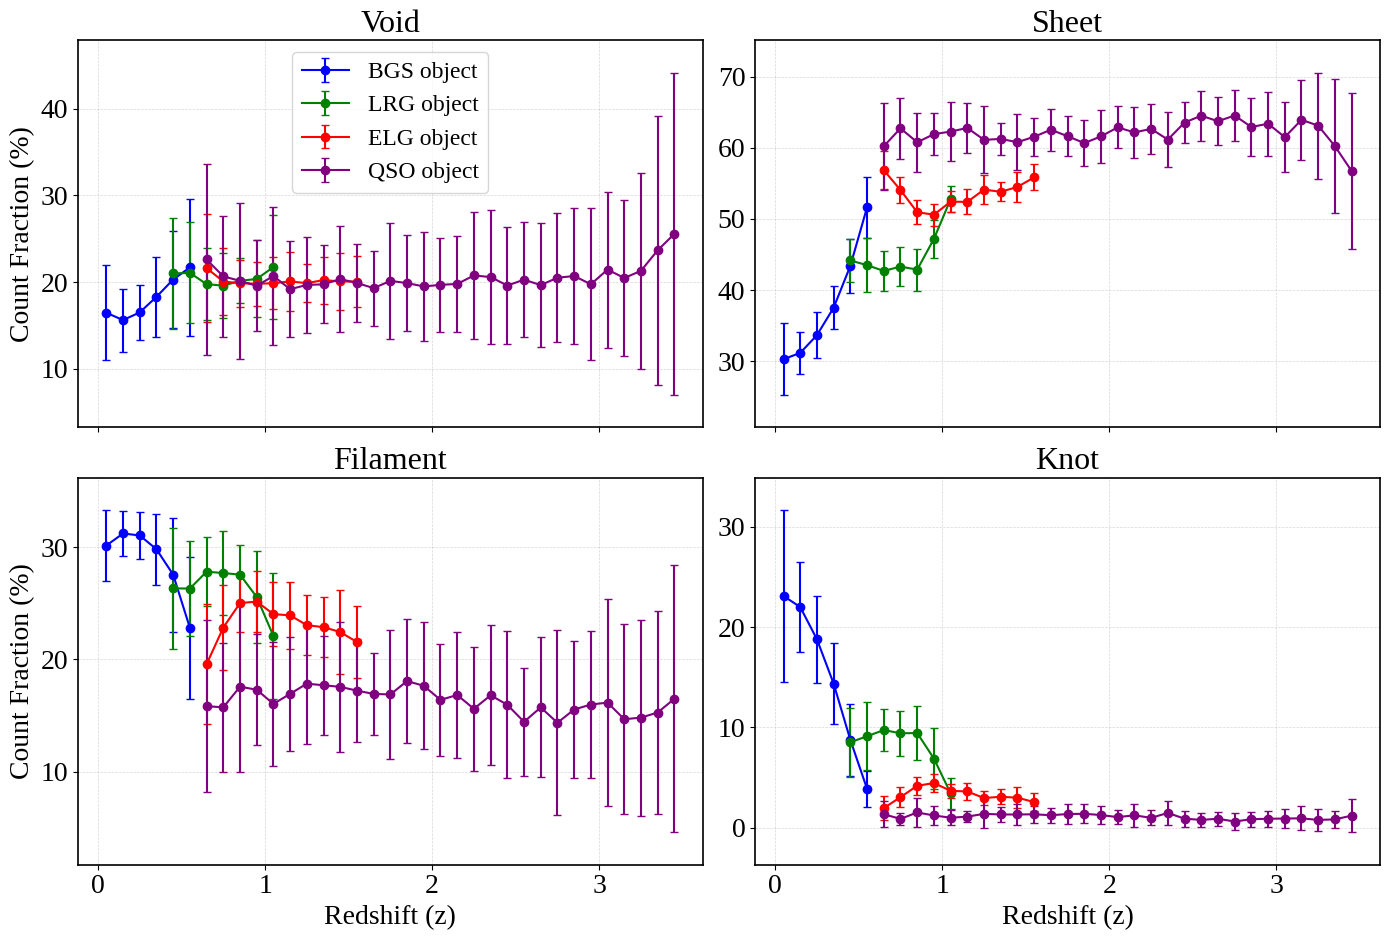

In [3]:
classes = ["void", "sheet", "filament", "knot"]
df_plot = ensure_z_center(df_all)
tracers = df_plot["tracer"].unique()

tracer_color_map = {
    tracer: color for tracer, color in zip(tracers, ["blue", "green", "red", "purple"])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for ax, cls in zip(axes.flatten(), classes):
    y_vals = []

    for tracer in tracers:
        sub = df_plot[
            (df_plot["tracer"] == tracer) &
            (df_plot["classification"] == cls)
        ]
        if len(sub) == 0:
            continue

        ax.errorbar(
            sub["z_center"],
            sub["mean_percentage"],
            yerr=sub["std_percentage"],
            marker="o",
            linestyle="-",
            capsize=3,
            label=tracer_display_label(tracer, "object"),
            color=tracer_color_map.get(tracer, "gray"),
            zorder=5
        )

        y_vals.extend((sub["mean_percentage"] - sub["std_percentage"]).values)
        y_vals.extend((sub["mean_percentage"] + sub["std_percentage"]).values)

    if len(y_vals) > 0:
        ymin = min(y_vals)
        ymax = max(y_vals)
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_title(cls.capitalize(), fontsize=TITLE_SIZE)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

axes[1, 0].set_xlabel("Redshift (z)", fontsize=X_LABEL_SIZE)
axes[1, 1].set_xlabel("Redshift (z)", fontsize=X_LABEL_SIZE)
axes[0, 0].set_ylabel("Count Fraction (%)", fontsize=Y_LABEL_SIZE)
axes[1, 0].set_ylabel("Count Fraction (%)", fontsize=Y_LABEL_SIZE)

axes[0, 0].legend(fontsize=LEGEND_SIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig = plt.gcf()
apply_regular_font_figure(fig)
fig.savefig(os.path.join(PLOTS_DIR, 'count_data.png'), dpi=300, bbox_inches='tight')
plt.show()


In [4]:
file = "/Users/soguevaram/Desktop/Research/DESI/data/results/count_fraction/classification_fractions_rand.xlsx" 
df_rand = pd.read_excel(file, sheet_name=None)  
df_all_rand = pd.concat(df_rand.values(), ignore_index=True)

df_all_rand["z_center"] = (df_all_rand["ZMIN"] + df_all_rand["ZMAX"]) / 2

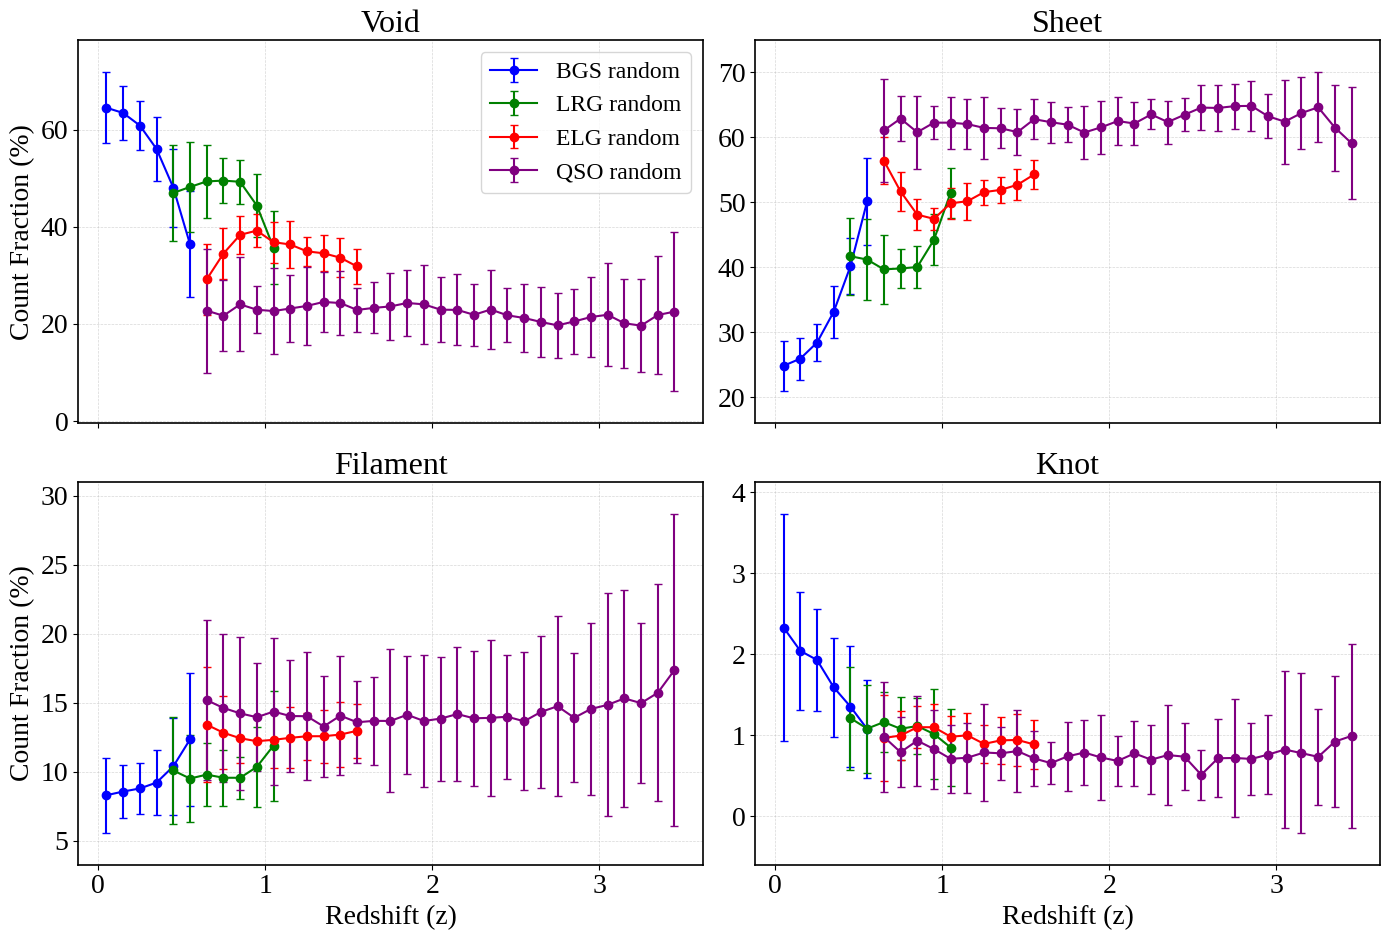

In [5]:
import matplotlib.pyplot as plt

classes = ["void", "sheet", "filament", "knot"]
df_plot_rand = ensure_z_center(df_all_rand)
tracers = df_plot_rand["tracer"].unique()

tracer_color_map = {
    tracer: color for tracer, color in zip(tracers, ["blue", "green", "red", "purple"])
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for ax, cls in zip(axes.flatten(), classes):
    y_vals = []

    for tracer in tracers:
        sub = df_plot_rand[
            (df_plot_rand["tracer"] == tracer) &
            (df_plot_rand["classification"] == cls)
        ]
        if len(sub) == 0:
            continue

        ax.errorbar(
            sub["z_center"],
            sub["mean_percentage"],
            yerr=sub["std_percentage"],
            marker="o",
            linestyle="-",
            capsize=3,
            label=tracer_display_label(tracer, "random"),
            color=tracer_color_map.get(tracer, "gray"),
            zorder=5
        )

        y_vals.extend((sub["mean_percentage"] - sub["std_percentage"]).values)
        y_vals.extend((sub["mean_percentage"] + sub["std_percentage"]).values)

    if len(y_vals) > 0:
        ymin = min(y_vals)
        ymax = max(y_vals)
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_title(cls.capitalize(), fontsize=TITLE_SIZE)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

axes[1, 0].set_xlabel("Redshift (z)", fontsize=X_LABEL_SIZE)
axes[1, 1].set_xlabel("Redshift (z)", fontsize=X_LABEL_SIZE)
axes[0, 0].set_ylabel("Count Fraction (%)", fontsize=Y_LABEL_SIZE)
axes[1, 0].set_ylabel("Count Fraction (%)", fontsize=Y_LABEL_SIZE)

axes[0, 0].legend(fontsize=LEGEND_SIZE)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig = plt.gcf()
apply_regular_font_figure(fig)
fig.savefig(os.path.join(PLOTS_DIR, 'count_random.png'), dpi=300, bbox_inches='tight')
plt.show()
